In [9]:
import pandas as pd
import numpy as np

import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt

from gnews import GNews
from datetime import datetime

import os
import time

from transformers import AutoTokenizer,AutoModelForSequenceClassification,pipeline,DistilBertTokenizer

In [1]:
'''gn = GNews(language='en', country='US', max_results=5)

# Top news
top = gn.get_top_news()

# Search by keyword
results = gn.get_news('artificial intelligence')

# By topic
tech_news = gn.get_news_by_topic('TECHNOLOGY')

# By location
india_news = gn.get_news_by_location('India')

# Full article
article = gn.get_full_article(results[0]['url'])
print(article.text))

def trim_csv_files(folder_path: str, output_folder: str = None):

    if output_folder is None:
        output_folder = folder_path
    else:
        os.makedirs(output_folder, exist_ok=True)

    for filename in os.listdir(folder_path):
        if not filename.lower().endswith(".csv"):
            continue

        file_path = os.path.join(folder_path, filename)

        try:
            # Efficient read
            df_trimmed = pd.read_csv(file_path, nrows=201)

            save_path = os.path.join(output_folder, filename)
            df_trimmed.to_csv(save_path, index=False)

            print(f"Processed: {filename}")

        except Exception as e:
            print(f"Skipping {filename}: {e}")'''

"gn = GNews(language='en', country='US', max_results=5)\n\n# Top news\ntop = gn.get_top_news()\n\n# Search by keyword\nresults = gn.get_news('artificial intelligence')\n\n# By topic\ntech_news = gn.get_news_by_topic('TECHNOLOGY')\n\n# By location\nindia_news = gn.get_news_by_location('India')\n\n# Full article\narticle = gn.get_full_article(results[0]['url'])\nprint(article.text))"

In [13]:
class NewsAcquirer:
    def __init__(self,language:str = 'en' ,max_results:int = 100):
        self.gn=GNews(language=language,max_results=max_results)

    def acquire_news_keyword(self,topic:str):
          try:
            print(topic)
            _=pd.DataFrame(self.gn.get_news(topic))
            _['time_of_collection']=datetime.now().strftime('%Y-%m-%d %H:%M:%S')
            _['time_of_collection'] = pd.to_datetime(_['time_of_collection'],format='mixed',dayfirst=True)
            print(_.head())
            time.sleep(10)
            _['published date']=pd.to_datetime(_['published date'])
            _['date'] = _['time_of_collection'].dt.normalize()
            _['ticker']=topic
            return _
            del _
          except Exception as e:
              print(f'Error:{e}')
              pass

    def acquire_news_top(self):
        return self.gn.get_top_news()

    def acquire_news_topic(self,topic:str):
        return self.gn.get_news(topic)

    #drops all rows that present in old_news
    def filter_new_news(self,new_news:pd.DataFrame,old_news:pd.DataFrame):
        x=0
        for index,title in enumerate(new_news.iloc[:,0]):
            if title in old_news.iloc[:,0].values:
                new_news.drop(index=index,axis=1,inplace=True)
                x=x+1
            else:
                pass
        print('Total news dropped:',x)

class NewsRecorder:

    def __init__(self, base_path:str = r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews"):
        self.base_path = base_path
        self.files = os.listdir(base_path)
        self.dfs=[]

    def _path_for(self, ticker: str) -> str:
        return os.path.join(self.base_path, f"{ticker}.csv")

    def record_news(self,new_news:pd.DataFrame,ticker:str,header:bool = True,mode:str = 'a'):
        new_news.to_csv(self._path_for(ticker=ticker),header=header,index=False,mode=mode)

    def load_all(self):
        for ticker in self.files:
             if not ticker.endswith('.csv'):
                continue
             temp = pd.read_csv(self.base_path+f'\\{ticker}')
             temp['ticker'] = ticker
             self.dfs.append(temp)

        return pd.concat(self.dfs, ignore_index=True)


class SentimentAnalyser:

    def __init__(self,base_path:str = r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews"):
        self.classifier = pipeline('text-classification',model="ProsusAI/finbert")
        self.base_path=base_path
        self.dfs=[]
        self.df=[]

    def _acquire_sentiment(self,new_news:pd.DataFrame):
        texts = new_news.iloc[:, 1].tolist()
        results = self.classifier(texts, top_k=None)
        probs = [{d['label']: d['score'] for d in res} for res in results]

        probs_df = pd.DataFrame(probs)

        new_news = pd.concat([new_news.reset_index(drop=True), probs_df], axis=1)
        new_news['label'] = probs_df.idxmax(axis=1)
        new_news['sentiment_score']=new_news['positive'] - new_news['negative']
        self.df=new_news

        return self.df

    def _acquire_sentiment_stats_market(self):
        market_sentiment = self.df.groupby('date').agg({'sentiment_score': ['mean', 'count', 'std']})
        market_sentiment.columns = ['mean_sentiment', 'news_count', 'sentiment_volatility']
        market_sentiment['sentiment_change'] = market_sentiment['mean_sentiment'].diff()

        return market_sentiment

    def _acquire_sentiment_stats_tickers(self):
        ticker_sentiment = self.df.groupby(['date', 'ticker']).agg({'sentiment_score': ['mean', 'count']})

        ticker_sentiment.columns = ['mean_sentiment', 'news_count']
        ticker_sentiment = ticker_sentiment.reset_index()
        ticker_sentiment['sentiment_change'] = ticker_sentiment.groupby('ticker')['mean_sentiment'].diff()

        return ticker_sentiment

    def acquire_sentiment_stats(self,loader:NewsRecorder):
        _df=loader.load_all()
        return self._acquire_sentiment(_df),self._acquire_sentiment_stats_market(),self._acquire_sentiment_stats_tickers()

class NewsPipeline:
    INDICES = ["Nifty 50", "Sensex", "S&P 500","Dow Jones Industrial Average", "NASDAQ Composite"]
    INDIAN_COMPANIES = ["Reliance Industries", "Tata Consultancy Services","HDFC Bank", "Infosys", "ICICI Bank"]
    US_COMPANIES = ["Apple Inc.", "Microsoft", "NVIDIA","Amazon", "Tesla", "Alphabet Inc."]

    def __init__(self, base_path: str = r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews"):
        self.acquirer = NewsAcquirer()
        self.recorder = NewsRecorder(base_path)
        self.analyser = SentimentAnalyser()


    def _all_tickers(self):
        return self.INDICES + self.US_COMPANIES + self.INDIAN_COMPANIES

    def run_acquisition(self):
        for ticker in self._all_tickers():
            try:
                _tempdf=self.acquirer.acquire_news_keyword(topic=ticker)
                self.recorder.record_news(new_news=_tempdf,ticker=ticker,header=False)
            except Exception as e:
                print(f'Error at run_acquisition {e}')
                pass

    def sentiment_analysis(self):
        main_df,market_sentiment_df,ticker_sentiment_df = self.analyser.acquire_sentiment_stats(loader=self.recorder)
        return main_df,market_sentiment_df,ticker_sentiment_df


In [11]:
newspipe=NewsPipeline()

03/28/2026 09:29:41 PM - HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors "HTTP/1.1 302 Found"


In [ ]:
newspipe.run_acquisition()

In [15]:
newspipe=NewsPipeline()
df,market_df,ticker_df=newspipe.sentiment_analysis()

03/28/2026 09:31:04 PM - HTTP Request: HEAD https://huggingface.co/ProsusAI/finbert/resolve/refs%2Fpr%2F29/model.safetensors "HTTP/1.1 302 Found"


In [16]:
df

,title,description,published date,url,publisher,time_of_collection,date,ticker,negative,neutral,positive,label,sentiment_score
0,Chip Selloff Deepens After Google Touts Memory...,Chip Selloff Deepens After Google Touts Memory...,"Thu, 26 Mar 2026 11:40:53 GMT",https://news.google.com/rss/articles/CBMijAFBV...,"{'href': 'https://finance.yahoo.com', 'title':...",2026-03-26 22:17:16,2026-03-26,Alphabet Inc..csv,0.842703,0.119496,0.037800,negative,-0.804903
1,Alphabet Quietly Entered A Multibillion-Dollar...,Alphabet Quietly Entered A Multibillion-Dollar...,"Wed, 25 Mar 2026 16:22:33 GMT",https://news.google.com/rss/articles/CBMipwFBV...,"{'href': 'https://seekingalpha.com', 'title': ...",2026-03-26 22:17:16,2026-03-26,Alphabet Inc..csv,0.013707,0.453912,0.532382,positive,0.518675
2,Meta and Google’s Addiction Verdict Turns the ...,Meta and Google’s Addiction Verdict Turns the ...,"Thu, 26 Mar 2026 09:00:07 GMT",https://news.google.com/rss/articles/CBMiuAFBV...,"{'href': 'https://www.bloomberg.com', 'title':...",2026-03-26 22:17:16,2026-03-26,Alphabet Inc..csv,0.083299,0.871881,0.044820,neutral,-0.038479
3,Alphabet Stock Gets a Boost From Waymo. Robo-T...,Alphabet Stock Gets a Boost From Waymo. Robo-T...,"Thu, 26 Mar 2026 14:49:00 GMT",https://news.google.com/rss/articles/CBMingNBV...,"{'href': 'https://www.barrons.com', 'title': ""...",2026-03-26 22:17:16,2026-03-26,Alphabet Inc..csv,0.009189,0.112954,0.877857,positive,0.868667
4,1 Brilliant Growth Stock to Buy Before It Join...,1 Brilliant Growth Stock to Buy Before It Join...,"Tue, 24 Mar 2026 22:45:00 GMT",https://news.google.com/rss/articles/CBMilgFBV...,"{'href': 'https://www.fool.com', 'title': 'The...",2026-03-26 22:17:16,2026-03-26,Alphabet Inc..csv,0.011114,0.909857,0.079029,neutral,0.067916
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4337,Tesla stock true believers could be losing fai...,Tesla stock true believers could be losing fai...,2026-03-25 19:50:32,https://news.google.com/rss/articles/CBMijgFBV...,"{'href': 'https://www.cnbc.com', 'title': 'CNBC'}",2026-03-28 21:05:15,2026-03-28,Tesla.csv,0.746318,0.234357,0.019325,negative,-0.726993
4338,An amputee cornhole champ is accused of murder...,An amputee cornhole champ is accused of murder...,2026-03-27 23:00:00,https://news.google.com/rss/articles/CBMioAFBV...,"{'href': 'https://dailyprogress.com', 'title':...",2026-03-28 21:05:15,2026-03-28,Tesla.csv,0.327206,0.648603,0.024191,neutral,-0.303015
4339,Man passed out in Tesla driving through Califo...,Man passed out in Tesla driving through Califo...,2026-03-27 13:26:48,https://news.google.com/rss/articles/CBMimwFBV...,"{'href': 'https://www.ktvu.com', 'title': 'KTVU'}",2026-03-28 21:05:15,2026-03-28,Tesla.csv,0.189639,0.778510,0.031851,neutral,-0.157787
4340,"Drunk Tesla Driver Gets a Nap, a DUI, and a Le...","Drunk Tesla Driver Gets a Nap, a DUI, and a Le...",2026-03-27 23:31:49,https://news.google.com/rss/articles/CBMihAFBV...,"{'href': 'https://www.yahoo.com', 'title': 'Ya...",2026-03-28 21:05:15,2026-03-28,Tesla.csv,0.089071,0.861794,0.049135,neutral,-0.039937


In [17]:
market_df

,mean_sentiment,news_count,sentiment_volatility,sentiment_change
date,,,,
2026-03-26,0.046484,1592,0.537270,NaN
2026-03-27,0.006554,1576,0.552938,-0.039929
2026-03-28,-0.057480,1174,0.525703,-0.064034


In [18]:
ticker_df

,date,ticker,mean_sentiment,news_count,sentiment_change
0,2026-03-26,Alphabet Inc..csv,-0.105781,100,NaN
1,2026-03-26,Amazon.csv,0.117626,100,NaN
2,2026-03-26,Apple Inc..csv,0.123067,100,NaN
3,2026-03-26,Dow Jones Industrial Average.csv,-0.227519,100,NaN
4,2026-03-26,HDFC Bank.csv,-0.272740,100,NaN
5,2026-03-26,ICICI Bank.csv,0.150953,100,NaN
6,2026-03-26,Infosys.csv,0.389970,92,NaN
7,2026-03-26,Microsoft.csv,-0.000086,100,NaN
8,2026-03-26,NASDAQ Composite.csv,-0.169299,100,NaN
9,2026-03-26,NVIDIA.csv,0.044202,100,NaN


In [3]:
path=r"C:\Users\Asus\Documents\Skills\Python\Sentiment Analysis\sentiment_gnews"

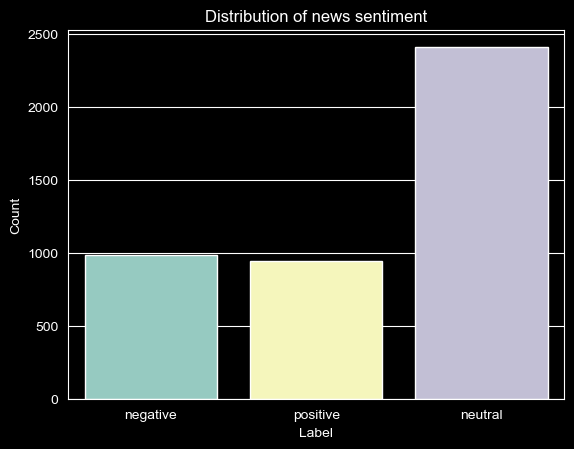

In [19]:
sns.countplot(data=df,x="label",hue="label")
plt.title('Distribution of news sentiment')
plt.ylabel('Count')
plt.xlabel('Label')
plt.show()

In [23]:
fig=go.Figure()
for time in df['date'].value_counts().index:
    fig.add_trace(go.Scatter(x=df[df['date']==time].index,y=df[df['date']==time]['sentiment_score'],mode='markers',name=str(time).rstrip('00:00:00')))
fig.show()